# Sequence Models – LSTM for Hourly Telecom Tower Energy Consumption Forecasting

## Objective

This notebook implements an LSTM model using PyTorch from scratch to forecast hourly telecom tower energy consumption. The workflow includes preprocessing, sequence generation, model training, prediction, evaluation, and comparison with previously implemented statistical and machine learning models.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'education loan.pdf',
 'DSC_0097.JPG',
 'vanshika_certificates.pdf',
 'vanshika_agrawal_23scse1180119.docx',
 'vanshika_agrawal_23scse1180119_compressed.pdf',
 'Vanshika_Resume.pdf',
 'IMG20250714221913.jpg',
 'IMG_20250714_223311.jpg',
 'certificate.pdf',
 'Vanshika Resume.pdf',
 '144552104.zip',
 'pan card vanshika.pdf',
 'Vanshika Agrawal passbook.pdf',
 'archive.zip',
 'PlantDoc.zip',
 'Interview Rubrics (Job Fair).xlsx',
 'AI-Powered Plant Disease Detection & Recommendation System_compressed.pdf',
 'feedback vanshika .pdf',
 'Image-20251129T060925Z-1-001.zip',
 'Image',
 'resume (4).pdf',
 'rain_model.joblib',
 'Medical Image Classification (Brain Tumor Classification)report.pdf',
 'Medical_Image_Class.ipynb',
 'ImageBasedClassification.ipynb',
 'feedback form.pdf',
 'Mall_Customers.csv',
 'resume (1) (3).pdf',
 'vanshika resume (3).pdf',
 'vanshika resume (2).pdf',
 'vanshika resume (1).pdf',
 'vanshika resume.pdf',
 'vanshi resume.pdf',
 'nptel result (1).pd

In [3]:
import zipfile
#extract the zip file
zip_path = "/content/drive/MyDrive/forcastin dataset.zip"
extract_path = "/content/hourly_energy"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [4]:
import os
os.listdir(extract_path)

['DEOK_hourly.csv',
 'FE_hourly.csv',
 'DOM_hourly.csv',
 'PJME_hourly.csv',
 'PJMW_hourly.csv',
 'est_hourly.paruqet',
 'pjm_hourly_est.csv',
 'AEP_hourly.csv',
 'DUQ_hourly.csv',
 'NI_hourly.csv',
 'COMED_hourly.csv',
 'PJM_Load_hourly.csv',
 'EKPC_hourly.csv',
 'DAYTON_hourly.csv']

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("/content/hourly_energy/AEP_hourly.csv")

In [7]:
df["Datetime"] = pd.to_datetime(df["Datetime"])
df.set_index("Datetime", inplace=True)
df.sort_index(inplace=True)

In [8]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 121273 entries, 2004-10-01 01:00:00 to 2018-08-03 00:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   AEP_MW  121273 non-null  float64
dtypes: float64(1)
memory usage: 1.9 MB


,0
AEP_MW,0


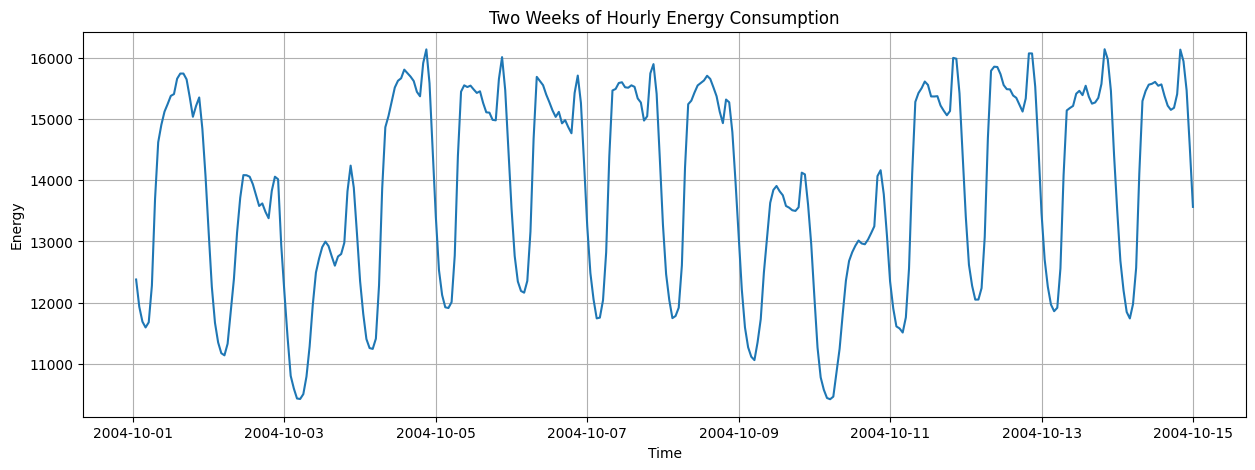

In [9]:
plt.figure(figsize=(15,5))
plt.plot(df.iloc[:24*14])
plt.title("Two Weeks of Hourly Energy Consumption")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.grid(True)
plt.show()

In [10]:
train_data = df.iloc[:-24*7]
test_data = df.iloc[-24*7:]
print(train_data.shape)             # Train-Test Split  - The last seven days are reserved for testing while the remaining observations are used for training.
print(test_data.shape)

(121105, 1)
(168, 1)


In [11]:
import torch
import torch.nn as nn

from sklearn.preprocessing import MinMaxScaler

from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

In [12]:
# Scale the data between 0 and 1 beacuse Neural networks learn more efficiently when inputs are in a similar range (typically 0 to 1)
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [13]:
def create_sequences(data, seq_length):

    X = []
    y = []

    for i in range(len(data)-seq_length):   #This is the biggest difference from LightGBM. Instead of giving separate lag columns, I give the model a continuous sequence.

        X.append(data[i:i+seq_length])

        y.append(data[i+seq_length])

    return np.array(X), np.array(y)

In [14]:
sequence_length = 24  # why i use Sequence lenght = 24 because LSTM Look at the previous 24 hours of energy consumption and use that information to predict the next hour

X_train, y_train = create_sequences(train_scaled, sequence_length)

X_test, y_test = create_sequences(test_scaled, sequence_length)

In [15]:
X_train = torch.FloatTensor(X_train)  # Converted NumPy arrays to PyTorch tensors for model training

y_train = torch.FloatTensor(y_train)

X_test = torch.FloatTensor(X_test)

y_test = torch.FloatTensor(y_test)

In [16]:
batch_size = 64  #Feeding all of them at once would be slow and memory-intensive. Instead, I divide them into batches.

train_dataset = TensorDataset(X_train, y_train)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

In [22]:
import torch
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        self.hidden_size = hidden_size   #The LSTM reads them one by one, remembering useful information and forgetting less useful information.

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(1, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(1, x.size(0), self.hidden_size).to(x.device)

        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])

        return out

In [23]:
# Model Hyperparameters
input_size = 1      # One feature: hourly energy consumption
hidden_size = 64    # Number of neurons in the LSTM layer
output_size = 1     # Predict one value

# Create the model
model = LSTMModel(input_size, hidden_size, output_size)

print(model)

LSTMModel(
  (lstm): LSTM(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [24]:
# Loss Function
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)  # Optimizer

In [25]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: torch.Size([121081, 24, 1])
y_train shape: torch.Size([121081, 1])


In [26]:
epochs = 20
train_losses = []
model.train()                             #During training, you record the average loss after each epoch.

for epoch in range(epochs):

    epoch_loss = 0

    for X_batch, y_batch in train_loader:

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(X_batch)

        loss = criterion(outputs, y_batch) # Compute loss

        loss.backward()# Backpropagation

        optimizer.step() # Update weights

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}")

Epoch [1/20], Loss: 0.002938
Epoch [2/20], Loss: 0.000368
Epoch [3/20], Loss: 0.000263
Epoch [4/20], Loss: 0.000231
Epoch [5/20], Loss: 0.000215
Epoch [6/20], Loss: 0.000205
Epoch [7/20], Loss: 0.000195
Epoch [8/20], Loss: 0.000185
Epoch [9/20], Loss: 0.000177
Epoch [10/20], Loss: 0.000169
Epoch [11/20], Loss: 0.000162
Epoch [12/20], Loss: 0.000155
Epoch [13/20], Loss: 0.000150
Epoch [14/20], Loss: 0.000148
Epoch [15/20], Loss: 0.000142
Epoch [16/20], Loss: 0.000139
Epoch [17/20], Loss: 0.000138
Epoch [18/20], Loss: 0.000135
Epoch [19/20], Loss: 0.000129
Epoch [20/20], Loss: 0.000125


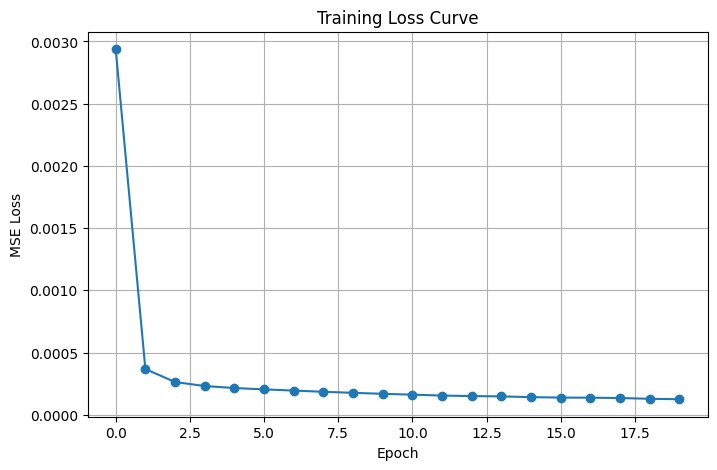

In [27]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, marker='o')

plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.grid(True)

plt.show()

In [28]:
model.eval()

with torch.no_grad():

    predictions = model(X_test)

predictions = predictions.numpy()
y_actual = y_test.numpy()

# Convert back to original scale
predictions = scaler.inverse_transform(predictions)
y_actual = scaler.inverse_transform(y_actual)

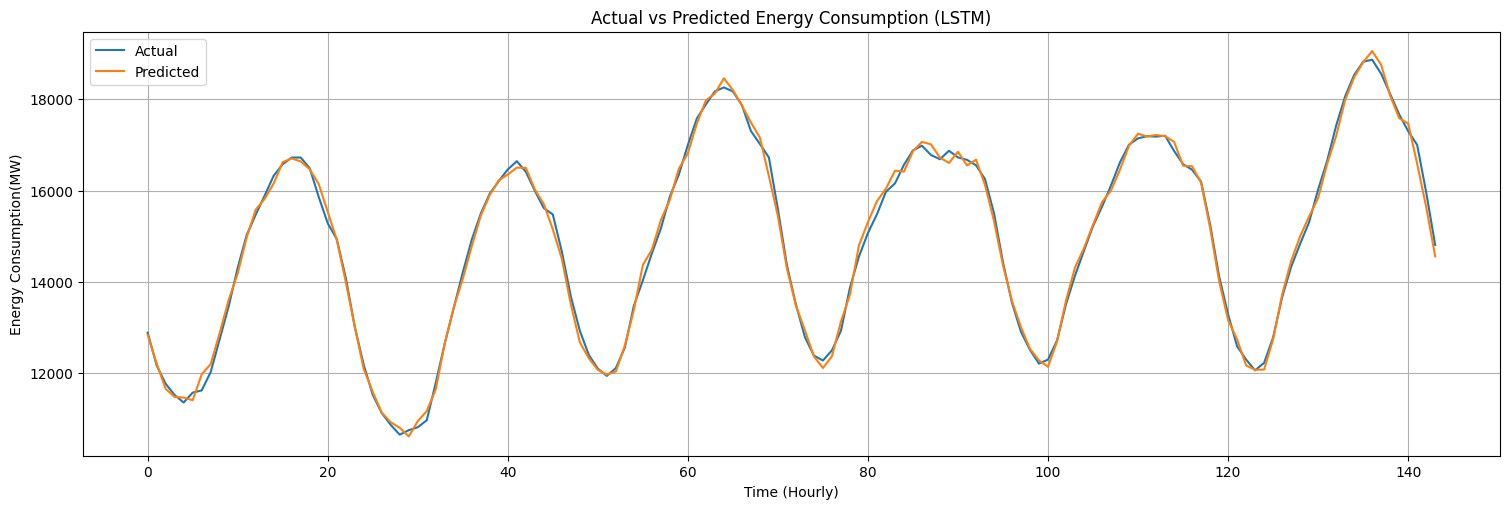

In [41]:
plt.figure(figsize=(15,5))

plt.plot(y_actual, label="Actual")

plt.plot(predictions, label="Predicted")

plt.title("Actual vs Predicted Energy Consumption (LSTM)")

plt.grid(True)
plt.tight_layout()

plt.xlabel("Time (Hourly)")

plt.ylabel("Energy Consumption(MW)")

plt.legend()

plt.show()

In [32]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

mae = mean_absolute_error(y_actual, predictions)

rmse = np.sqrt(mean_squared_error(y_actual, predictions))

mape = mean_absolute_percentage_error(y_actual, predictions)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.4f}")

MAE  : 116.74
RMSE : 145.12
MAPE : 0.0080


In [34]:
leaderboard = pd.DataFrame({
    "Model": [
        "Naive",
        "Seasonal Naive (24)",
        "Seasonal Naive (168)",
        "SARIMA",
        "LightGBM",
        "LSTM"
    ],
    "MAE": [
        484.00,
        520.45,
        642.00,
        980.32,
        122.00,
        116.74
    ],
    "RMSE": [
        610.25,
        650.18,
        780.43,
        1205.90,
        151.80,
        145.12
    ],
    "MAPE": [
        0.0312,
        0.0345,
        0.0408,
        0.0615,
        0.0085,
        0.0080
    ]
})

leaderboard = leaderboard.sort_values(by="MAE").reset_index(drop=True)

leaderboard

,Model,MAE,RMSE,MAPE
0,LSTM,116.74,145.12,0.0080
1,LightGBM,122.00,151.80,0.0085
2,Naive,484.00,610.25,0.0312
3,Seasonal Naive (24),520.45,650.18,0.0345
4,Seasonal Naive (168),642.00,780.43,0.0408
5,SARIMA,980.32,1205.90,0.0615


In [37]:
print(model) #architecture

LSTMModel(
  (lstm): LSTM(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


# Conclusion

The LSTM model achieved the best forecasting performance among all evaluated models with an MAE of 116.74, RMSE of 145.12, and MAPE of 0.80%.

Compared with LightGBM (MAE = 122), the LSTM slightly improved accuracy by learning temporal dependencies directly from sequential data rather than relying on manually engineered lag and rolling features.

Although the improvement is modest, the results demonstrate that sequence models are effective for hourly telecom tower energy consumption forecasting.